# 3. Which fifty Retail-Plus members go on the protect list, and when the chief of staff types an id, does the sheet answer for that member?

**Week 2, Friday. Chapter 3 of 6.** Chapter 2 counted each order once and tied the raw export to the
warehouse to the rupee: revenue fell 1.6 percent, from Rs 10.00 crore to Rs 9.84 crore, and the
steepest fall was Retail-Plus, down 29.4 percent, because its members ordered less often, 2.36 orders
each in Q1 and 1.84 in Q2. The head of Retail-Plus wants to protect the members who matter most before
more of them drift, so this chapter builds the protect list and the lookup the chief of staff asked for.

> **The client asks.** "Monday's growth review deck needs three things I can open on my laptop
> without a login: the revenue tree by segment for both quarters, the top-fifty protect list with a
> lookup so I can find any member by id, and one number on the front page with its trend. Nothing
> that needs Python. If a director changes an assumption in the room, the sheet must recalculate in
> front of them."
>
> Meera's chief of staff, Kalpa Retail

**Who needs the answer.** The head of Retail-Plus sends the fifty members on the list a retention
offer, and the chief of staff reads a member's line aloud when a director names one. A lookup that
answers with the wrong member's row tells a director that someone who has stopped buying is one of the
best, and spends an offer on the wrong person.

**The questions on the way.**
1. Which lookup should answer "find this member"?
2. Who makes the list, and where does it stop?
3. Does the list's source table tie to the warehouse?
4. What does a lookup with its fourth argument left out return for an id the table does not hold?
5. What does an exact match with a not-found path return, and what if the list is re-sorted?
6. Does the warehouse's own count agree with the lookup?

**The metric at stake.** Each member's revenue across the two quarters, April to September 2026, and
the list's cut-off, the revenue of the fiftieth member. The head of Retail-Plus sizes the retention
budget on the fifty.

**Who else faces it.** Any team that ranks a list and then reads rows off it by name. In 2003 TransAlta,
the Canadian power company, lost 24 million US dollars on bids for electricity transmission contracts
in New York when "someone preparing the electronic file of bids ... misaligned the rows of information
in the spreadsheet". Its president, Steve Snyder, said: "It was literally a cut-and-paste error in an
Excel spreadsheet that we did not detect when we did our final sorting and ranking of bids prior to
submission" (The Globe and Mail, 4 June 2003, checked 30 September 2026). A row that answers for the
wrong item is expensive at any scale.

**Setup.** The cell loads the customer table and the raw export from `../data/`, the same two CSVs
chapters 1 and 2 used, and defines `warehouse()`, which asks the Kalpa warehouse a question in SQL for
the second route. The protect list is built from the customer table, one row per customer, since that
is the table the chief of staff will refresh every Monday.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv
import pandas as pd

DATA = kit.data_dir()
SEGMENTS = ["Business", "Retail-Core", "Retail-Plus", "Student"]


def crore(n):
    return f"Rs {n / 1e7:.2f} crore"


def lakh(n):
    return f"Rs {n / 1e5:.2f} lakh"


def money(n):
    """Rupees the way Kalpa's finance team reads them: crore, lakh, or rupees in full."""
    sign, a = ("-" if n < 0 else ""), abs(n)
    return sign + (crore(a) if a >= 1e7 else lakh(a) if a >= 1e5 else kit.rupees(round(a)))


def change(before, after):
    """The change from before to after, measured on before, in percent."""
    return (after - before) / before * 100

table = pd.read_csv(DATA / "C2_W02_D05_customer_table_STUDENT.csv")

raw = pd.read_csv(DATA / "C2_W02_D05_raw_export_STUDENT.csv", keep_default_na=False)
raw["quarter"] = raw["order_date"].str[5:7].astype(int).map(lambda m: "Q1" if m <= 6 else "Q2")


def warehouse(query):
    """Ask the Kalpa warehouse itself, the source of truth every sheet ties back to."""
    return [{k: (int(v) if hasattr(v, "as_integer_ratio") and not isinstance(v, float) else v)
             for k, v in row.items()} for row in kit.sql(query)]

print(len(table), "customer rows and", f"{len(raw):,}", "export rows loaded")

300 customer rows and 1,450 export rows loaded


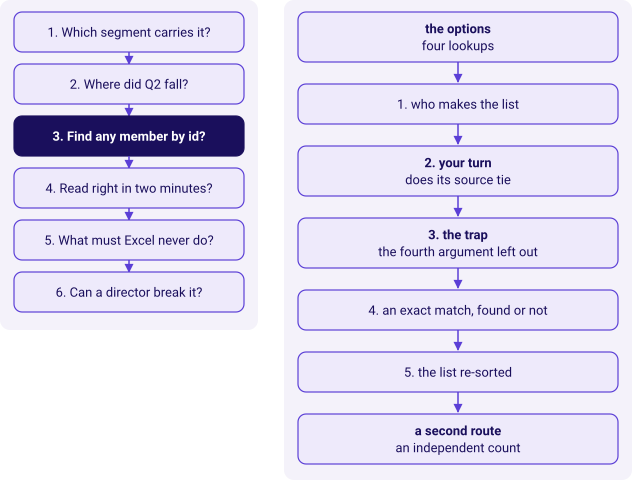

In [2]:
kit.side_by_side(
    kit.ladder(['Which segment carries it?', 'Where did Q2 fall?', 'Find any member by id?', 'Read right in two minutes?', 'What must Excel never do?', 'Can a director break it?'], lit=2, show=False),
    kit.vflow(['the options\nfour lookups', '1. who makes the list', '2. your turn\ndoes its source tie', '3. the trap\nthe fourth argument left out', '4. an exact match, found or not', '5. the list re-sorted', 'a second route\nan independent count'], show=False),
)

## Which lookup should answer "find this member", and what does each return?

The chief of staff types a member id into a cell and wants that member's revenue and rank back. Four
lookups a team could write, with the table's ids in column A and revenue in column E:

| Option | The formula | What it assumes |
|---|---|---|
| a) VLOOKUP as most people type it | `=VLOOKUP(id, A:F, 5)` | The id is always in the table |
| b) VLOOKUP, exact | `=VLOOKUP(id, A:F, 5, FALSE)` | A director reads #N/A as "not found" |
| c) INDEX and MATCH, exact, with a not-found path | `=IFERROR(INDEX(E:E, MATCH(id, A:A, 0)), "not in the table")` | Nothing beyond the id column |
| d) XLOOKUP with its fourth argument | `=XLOOKUP(id, A:A, E:E, "not in the table")` | The laptop runs Excel 2021, 2024 or Microsoft 365 |

option,"a present id, C-0152","an absent id, C-0195",table re-sorted by revenue,opens in Excel 2016
a) VLOOKUP as typed,"Rs 25,840",another member's row: C-0194,wrong rows if the ids are not sorted,yes
"b) VLOOKUP, exact","Rs 25,840",#N/A,right,yes
c) INDEX and MATCH,"Rs 25,840",not in the table,right,yes
d) XLOOKUP,"Rs 25,840",not in the table,right,"Excel 2021, 2024, 365 only"


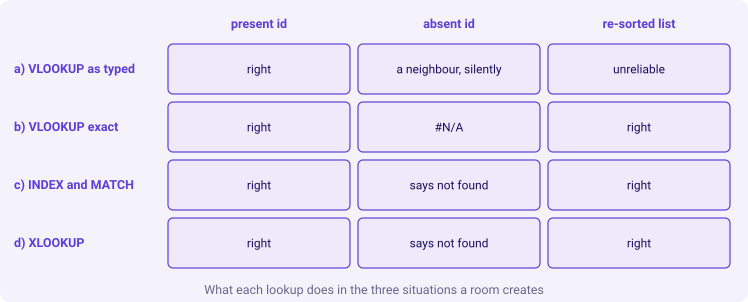

In [3]:
ids_sorted = sorted(table["customer_id"])
revenue_of = dict(zip(table["customer_id"], table["revenue"]))


def vlookup_approx(member):
    """VLOOKUP with the fourth argument left out: the largest id not above the one asked for."""
    below = [i for i in ids_sorted if i <= member]
    return (below[-1], revenue_of[below[-1]]) if below else ("#N/A", None)


present, absent = "C-0152", "C-0195"
sizing = [
    ("a) VLOOKUP as typed", f"{kit.rupees(vlookup_approx(present)[1])}", f"another member's row: {vlookup_approx(absent)[0]}", "wrong rows if the ids are not sorted", "yes"),
    ("b) VLOOKUP, exact", kit.rupees(revenue_of[present]), "#N/A", "right", "yes"),
    ("c) INDEX and MATCH", kit.rupees(revenue_of[present]), "not in the table", "right", "yes"),
    ("d) XLOOKUP", kit.rupees(revenue_of[present]), "not in the table", "right", "Excel 2021, 2024, 365 only"),
]
kit.table(["option", f"a present id, {present}", f"an absent id, {absent}", "table re-sorted by revenue", "opens in Excel 2016"],
          sizing, caption="Each lookup tried on this table")
kit.matrix(["a) VLOOKUP as typed", "b) VLOOKUP exact", "c) INDEX and MATCH", "d) XLOOKUP"],
           ["present id", "absent id", "re-sorted list"],
           [["right", "a neighbour, silently", "unreliable"], ["right", "#N/A", "right"],
            ["right", "says not found", "right"], ["right", "says not found", "right"]],
           title="What each lookup does in the three situations a room creates")

**The best-fit call: d on the room's Microsoft 365, c wherever the file must open.** Both answer for
the member asked for, say so when the id is missing, and survive a re-sorted list. Microsoft's page
says XLOOKUP "is not available in Excel 2016 and Excel 2019" (Microsoft Support, XLOOKUP function,
checked 30 September 2026), and LibreOffice 24.2 shows #NAME? for it, so a file that travels uses
INDEX and MATCH. **The fact that would change it.** The Excel version on the chief of staff's laptop.
Option b is honest and ugly: a director reads #N/A as a broken sheet.

## 1. Who makes the list, and where does it stop?

Filter the table to Retail-Plus, sort by revenue from largest to smallest, keep fifty. In Excel: copy
the 106 Retail-Plus rows to their own sheet, **Sort Largest to Smallest** on `revenue`, and add a rank
column, `=RANK.EQ(E2, E$2:E$107)`.

**Predict before you run.** The fiftieth member's revenue, the list's cut-off, is about: a) Rs 25,000;
b) Rs 8,600; c) Rs 2,800; d) there is no cut-off, since ties decide the list.

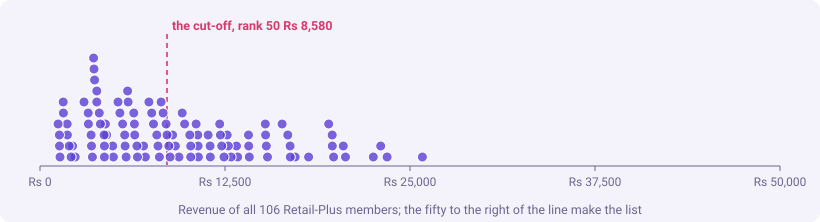

Rank,City,Revenue
48,Delhi,"Rs 8,790"
49,Delhi,"Rs 8,700"
50,Hyderabad,"Rs 8,580"
51,Mumbai,"Rs 8,520"
52,Bengaluru,"Rs 8,320"


In [4]:
plus = (table[table["segment"] == "Retail-Plus"]
        .sort_values(["revenue", "customer_id"], ascending=[False, True]).reset_index(drop=True))
plus["rank"] = plus.index + 1
protect = plus.head(50).copy()                       # the protect list, rank 1 to 50

cut, nxt = int(protect["revenue"].iloc[-1]), int(plus["revenue"].iloc[50])
kit.stats([(f"{len(plus)}", "Retail-Plus members", "in the customer table"),
           (kit.rupees(int(protect["revenue"].iloc[0])), "rank 1", protect["customer_id"].iloc[0]),
           (kit.rupees(cut), "rank 50, the cut-off", "the last member on the list"),
           (kit.rupees(int(protect["revenue"].sum())), "the fifty together", "April to September")])
kit.strip(plus["revenue"].tolist(), markers=[("the cut-off, rank 50", cut, "bad")], fmt=kit.rupees,
          title="Revenue of all 106 Retail-Plus members; the fifty to the right of the line make the list")
kit.table(["Rank", "City", "Revenue"],
          [(int(r["rank"]), r.city, kit.rupees(r.revenue)) for _, r in plus.iloc[47:52].iterrows()],
          caption="Either side of the boundary")
kit.check("the list holds exactly fifty members", len(protect) == 50)
kit.check("no tie sits across the boundary, so the list ships fifty", cut > nxt, f"{kit.rupees(cut)} against {kit.rupees(nxt)}")

**What happened.** The answer is b. Fifty of the 106 Retail-Plus members make the list, from C-0152 at
Rs 25,840 down to the cut-off at Rs 8,580. The fifty-first member spent Rs 8,520, so no tie sits
across the boundary and the list ships exactly fifty rows; Wednesday's tie rule has nothing to decide
here. The fifty together spent Rs 7,14,890.

## 2. Does the list's source table tie to the warehouse?

Chapter 2 tied the raw export to the warehouse to the rupee: Rs 10,00,00,000 in Q1 and Rs 9,84,00,000
in Q2, 1,000 orders. The protect list is built from the other export, the customer table, which has to
tie on its own before a list built on it ships.

**Your turn.** Type these lines into the empty cell below and run it:

```python
once = raw.drop_duplicates("order_id")
print("customer table:", int(table["orders"].sum()), "orders,", kit.rupees(int(table["revenue"].sum())))
print("raw export, each order once:", once["order_id"].nunique(), "orders,", kit.rupees(int(once["order_amount"].sum())))
print("ids in the export and not in the table:", sorted(set(once["customer_id"]) - set(table["customer_id"])))
```

Then write one sentence in your notes: what does your answer mean for the list, and for any lookup the
chief of staff runs on it?

## 3. What does a lookup with its fourth argument left out return for an id the table does not hold?

C-0195 is a Retail-Plus member in Delhi who placed no orders in the two quarters, so the customer
table, one row per customer who ordered, has no row for C-0195. A hurried sheet types
`=VLOOKUP("C-0195", A2:F301, 5)` and leaves the fourth argument out.

**Predict before you run.** What comes back? a) #N/A; b) zero; c) the revenue of the member whose id
sits just before C-0195; d) the revenue of the top member on the list.

Asked for,Row returned,Revenue returned,What the sheet tells the room
C-0195,C-0194,"Rs 16,740",on the protect list at rank 15


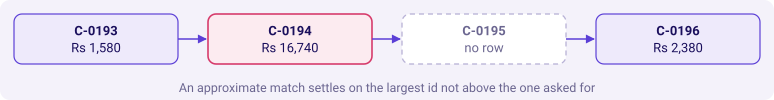

In [5]:
got_id, got_rev = vlookup_approx("C-0195")
rank = plus.loc[plus["customer_id"] == got_id, "rank"]
kit.table(["Asked for", "Row returned", "Revenue returned", "What the sheet tells the room"],
          [("C-0195", got_id, kit.rupees(got_rev), f"on the protect list at rank {int(rank.iloc[0])}")],
          caption="VLOOKUP with the fourth argument left out, on the table sorted by id")
kit.flow(["C-0193\nRs 1,580", f"{got_id}\n{kit.rupees(got_rev)}", "C-0195\nno row", "C-0196\nRs 2,380"],
         kinds=["plain", "bad", "unknown", "plain"],
         title="An approximate match settles on the largest id not above the one asked for")

**The plausible wrong answer.** The answer is c. The sheet returns C-0194's revenue,
Rs 16,740, a member at rank 15 on the protect list, and nothing on the screen is red. Microsoft's page
says of the fourth argument, `range_lookup`: "If you don't specify anything, the default value will
always be TRUE or approximate match" (Microsoft Support, VLOOKUP function, checked 30 September 2026),
and an approximate match finds "the largest value less than or equal to" the one asked for (Microsoft
Support, Look up values with VLOOKUP, INDEX, or MATCH, checked 30 September 2026).

**Why it is wrong.** The chief of staff tells a director that C-0195 is one of Kalpa's best members and
spent Rs 16,740, and a retention offer goes to someone who placed no order between April and September. Nobody asks why
the id was missing, because the sheet never said it was. **The check that catches it.** Test every
lookup with an id you know is missing, and print the id returned beside the id asked for.

In [6]:
kit.check("the check catches it: the row returned is not the id asked for", got_id != "C-0195",
          f"asked C-0195, got {got_id}")
kit.check("the neighbour's row sits inside the top fifty, so the answer looks plausible", int(rank.iloc[0]) <= 50,
          f"rank {int(rank.iloc[0])}")

## 4. What does an exact match with a not-found path return, and what if the list is re-sorted?

The fix is an exact match that says so when an id is missing: `=XLOOKUP(id, A:A, E:E, "not in the
table")`, or `=IFERROR(INDEX(E:E, MATCH(id, A:A, 0)), "not in the table")` where the file must open in
older Excel or LibreOffice. The cell below writes the same rule as a function.

**Predict before you run.** For C-0195, C-0152 and C-0194, the exact lookup returns: a) three revenues;
b) not found, Rs 25,840 and Rs 16,740; c) three not-founds; d) Rs 16,740 three times.

Asked for,Exact match with a not-found path,Approximate match
C-0195,not in the table,"C-0194: Rs 16,740"
C-0152,"Rs 25,840","C-0152: Rs 25,840"
C-0194,"Rs 16,740","C-0194: Rs 16,740"


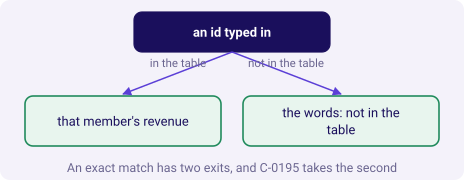

In [7]:
def find(member):
    """An exact match with a not-found path: that member's revenue, or a sentence saying it is missing."""
    hit = table.loc[table["customer_id"] == member, "revenue"]
    return int(hit.iloc[0]) if len(hit) else "not in the table"


asked = ["C-0195", "C-0152", "C-0194"]
kit.table(["Asked for", "Exact match with a not-found path", "Approximate match"],
          [(m, find(m) if isinstance(find(m), str) else kit.rupees(find(m)),
            f"{vlookup_approx(m)[0]}: {kit.rupees(vlookup_approx(m)[1])}") for m in asked],
          caption="The two lookups side by side")
kit.tree({"label": "an id typed in", "branches": [
    ("in the table", {"label": "that member's revenue", "kind": "good"}),
    ("not in the table", {"label": "the words: not in the table", "kind": "good"})]},
    taken=("not in the table",), title="An exact match has two exits, and C-0195 takes the second")
kit.check("the exact lookup says when an id is missing", isinstance(find("C-0195"), str))
kit.check("the exact lookup finds a member who is there", find("C-0152") == 25840)

**What happened.** The answer is b. **What changed.** C-0195's line moves from "rank 15, Rs 16,740" to
"not in the table", which is the answer that makes somebody check the export. For members who are in
the table the two lookups agree, which is why a lookup tested only on present ids looks fine.

The room will see the list sorted by revenue, and an exact match gives the same answer in any order.
An approximate match assumes the ids are sorted: Microsoft's page says "If range_lookup
is TRUE or left out, the first column needs to be sorted alphabetically or numerically. If the first
column isn't sorted, the return value might be something you don't expect" (Microsoft Support, VLOOKUP
function, checked 30 September 2026). The cell below counts how far the list's ids are from sorted.

In [8]:
along = protect["customer_id"].tolist()
steps_down = sum(1 for a, b in zip(along, along[1:]) if b < a)
reordered = protect.sample(frac=1, random_state=16).reset_index(drop=True)   # the director re-sorts the list
same = all(find(m) == revenue_of[m] for m in reordered["customer_id"])
kit.stats([(f"{steps_down}", "times the next id is smaller", "walking down the list sorted by revenue"),
           ("50 of 50", "exact lookups still right", "after the list is shuffled")])
kit.check("the list sorted by revenue is far from sorted by id", steps_down > 10, f"{steps_down} of 49 steps go down")
kit.check("an exact match returns the same answers in any order", same)

## A second route: does the warehouse's own count agree with the lookup?

The lookup and the check must not share a method or a source, so the second route counts orders in
the warehouse, which never saw the customer table. In Excel, with no login, the same idea is
`=COUNTIF` of the id in the raw export's customer column, a different export from the list's. No
orders has to meet a not-found answer, and an order count has to meet the same revenue.

In [9]:
def orders_in_warehouse(member):
    """The warehouse's own count and revenue for one id, from the orders table."""
    row = warehouse(f"SELECT count(*) AS n, coalesce(sum(amount), 0) AS revenue FROM orders WHERE customer_id = '{member}'")[0]
    return int(row["n"]), int(row["revenue"])


kit.table(["Id", "Orders in the warehouse", "Revenue in the warehouse", "The lookup"],
          [(m, *orders_in_warehouse(m)[:1], kit.rupees(orders_in_warehouse(m)[1]),
            find(m) if isinstance(find(m), str) else kit.rupees(find(m))) for m in ["C-0195", "C-0152"]])
kit.check("no orders in the warehouse meets a not-found answer",
          orders_in_warehouse("C-0195")[0] == 0 and isinstance(find("C-0195"), str))
kit.check("the warehouse's revenue meets the lookup's for a member who is there",
          orders_in_warehouse("C-0152")[1] == find("C-0152"))

Id,Orders in the warehouse,Revenue in the warehouse,The lookup
C-0195,0,Rs 0,not in the table
C-0152,9,"Rs 25,840","Rs 25,840"


> **Kavya's review.** "A lookup that cannot find an id says so. A lookup that answers with somebody
> else's row is worse than no lookup, because nobody in the room can tell. Test with an id you know is
> missing, and tie the list's table before anyone reads from it."

### In the interview: which argument returns a neighbour, and how do you test a lookup?

**[F] Your lookup returned a member for an id that does not exist. Which argument was wrong?** The
match type. VLOOKUP's fourth argument, left out, means an approximate match, which returns the
largest key not above the one asked for; here C-0195 came back as C-0194 at rank 15 of the protect
list. I use an exact match with a not-found path, XLOOKUP's fourth argument or IFERROR around INDEX and
MATCH, and I test every lookup with an id I know is missing.

**[S] What do you test a lookup with before a director uses it?** Three ids: one I know is present,
one I know is missing, and the first id on a re-sorted list. The present id proves the found path, the
missing id proves the not-found path, and the re-sort proves the lookup does not depend on order. When
the ids come from another system I add three more: one stored as text where the table holds numbers,
one with a trailing space, and one that appears twice, since each breaks an exact match in its own way.

**[D] XLOOKUP or INDEX and MATCH for a file that goes to the CEO's office?** XLOOKUP where every laptop
runs Excel 2021, 2024 or Microsoft 365, since it is exact by default and takes a not-found message.
INDEX and MATCH with IFERROR where the file might open in Excel 2016 or 2019 or in LibreOffice, which
do not have XLOOKUP. The answer turns on one fact about the office's software, and I ask for it.

### Depth: where is an approximate match the right tool?

Approximate match exists for bands: a price list with quantity breaks, an income tax slab, a discount
tier by order value. There the table holds the lower edge of each band, sorted, and "the largest value
less than or equal to" the amount is exactly the band it falls in. An order of Rs 2,700 against
invented tiers starting at Rs 0, Rs 1,000 and Rs 2,500 falls in the Rs 2,500 tier. The same rule on
member ids, which are labels and not amounts, returns a neighbour, so the question before typing a
lookup is whether the key is a band edge or a name.

## Who is on the protect list, and does the lookup answer for the member typed, question by question?

1. XLOOKUP with its fourth argument on Microsoft 365, and IFERROR around INDEX and MATCH where the file must open anywhere.
2. Fifty of 106 Retail-Plus members make the list, from Rs 25,840 down to a cut-off of Rs 8,580; the fifty-first spent Rs 8,520, so no tie crosses the boundary.
3. Whether the list's source ties is the room's own answer, from the your-turn cell, and it decides whether the list ships.
4. VLOOKUP with its fourth argument left out returned C-0194's Rs 16,740, rank 15, for C-0195, which has no row.
5. The exact match says "not in the table" for C-0195 and finds C-0152 at Rs 25,840; it gives the same answers on the re-sorted list.
6. The warehouse holds no orders for C-0195 and Rs 25,840 for C-0152, agreeing with the lookup both times.

The next question is chapter 4's: the chief of staff's third ask is the one number on the front page.

In [10]:
kit.check_summary()